<a href="https://colab.research.google.com/github/xEzIxX/AI-Class/blob/master/week4/titanic_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:

import pandas as pd
import numpy as np;

file_path = '/content/drive/MyDrive/Colab Notebooks/titanic.csv';

# 데이터 읽기
df = pd.read_csv(file_path);

# 상위 5개 행 확인
# print(df.head());
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Text(0.5, 1.0, 'Label')

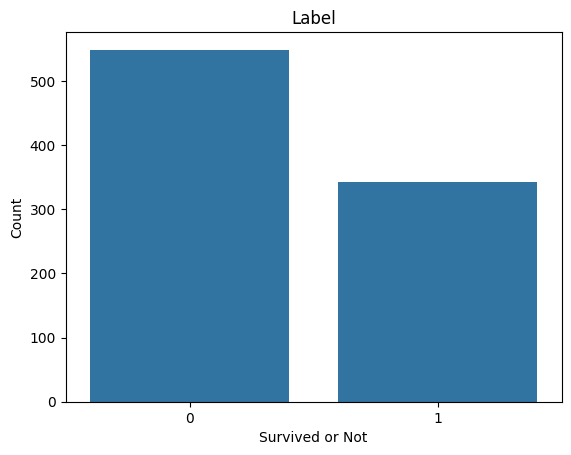

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# 레이블 갯수 확인 (그래프)
sns.countplot(data = df, x="Survived")
plt.xlabel("Survived or Not")
plt.ylabel("Count")
plt.title("Label")

In [3]:
# 칼럼별 결측치 개수 확인
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [4]:
# 데이터 분석에 불필요한 데이터 삭제
# 머신러닝 알고리즘은 숫자 데이터만 처리할 수 있음
df = df.drop(['Name', 'Ticket', 'Cabin'], axis=1)
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Sex              0
Age            177
SibSp            0
Parch            0
Fare             0
Embarked         2
dtype: int64


In [11]:
# Age는 중앙값을 넣어준다.
# 유의미한 데이터이므로 177개의 데이터를 날리기보단 평균값을 넣는 방향으로 진행

df['Age'] = df['Age'].fillna(df['Age'].median())

# 선착장(문자열)은 최빈값(가장 많이 나온 값)으로 채우기
# .mode()[0]을 붙이면 가장 빈도가 높은 값을 넣어준다.
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64


In [23]:
# 문자열 컬럼 인코딩

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

X.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,3,1,22.0,1,0,7.2500,2
1,2,1,0,38.0,1,0,71.2833,0
2,3,3,0,26.0,0,0,7.9250,2
3,4,1,0,35.0,1,0,53.1000,2
4,5,3,1,35.0,0,0,8.0500,2


In [13]:
# 정답(label) 데이터 설정
# Survived = 생존 여부
y=df['Survived'];
print(y.value_counts());

Survived
0    549
1    342
Name: count, dtype: int64


In [14]:
# 입력 데이터(feature) 생성 : 정답 데이터 제외하는 과정
X=df.drop('Survived',axis=1)

X.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,3,1,22.0,1,0,7.2500,2
1,2,1,0,38.0,1,0,71.2833,0
2,3,3,0,26.0,0,0,7.9250,2
3,4,1,0,35.0,1,0,53.1000,2
4,5,3,1,35.0,0,0,8.0500,2


In [15]:
from sklearn.model_selection import train_test_split

# 학습 데이터 / 테스트 데이터 분리
# 25퍼센트를 테스트 케이스로 준다
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25,random_state=0)

In [16]:
# Logistic Regression 모델 생성
# 입력 특징을 이용하여 "생존할 활률"을 계산하고, 그 확률을 기반으로 생존 여부를 확인
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

# 모델 학습 (훈련 데이터로 패턴 학습)
clf_lr = LogisticRegression(random_state=0) # 머신러닝 모델 빌드
clf_lr.fit(X_train, y_train) # 훈련

pred_lr = clf_lr.predict(X_test) # 예측한 값 입력

# 모델 성능 평가
print ("\n--- Logistic Regression Classifier ---")
print (accuracy_score(y_test, pred_lr)) # 전체 예측 중 맞춘 비율
print (confusion_matrix(y_test, pred_lr)) # 실제값 vs 예측값 비교 행렬



--- Logistic Regression Classifier ---
0.7847533632286996
[[116  23]
 [ 25  59]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [17]:
# Decision Tree 모델 생성
# 입력 feature 값을 기준으로 데이터를 분할하고
# 가장 잘 클래스가 구분되는 기준을 선택하여 트리 구조로 분류하는 모델
from sklearn.tree import DecisionTreeClassifier

# 모델 학습 (훈련 데이터로 분류 규칙 학습)
clf_dt = DecisionTreeClassifier(random_state=0) # 머신러닝 모델 빌드
clf_dt.fit(X_train, y_train) # 훈련

# 테스트 데이터로 클래스 예측
pred_dt = clf_dt.predict(X_test)

# 모델 성능 평가
print("\n--- Decision Tree Classifier ---")
print(accuracy_score(y_test, pred_dt)) # 전체 예측 중 맞춘 비율
print(confusion_matrix(y_test, pred_dt)) # 실제값 vs 예측값 비교 행렬


--- Decision Tree Classifier ---
0.7757847533632287
[[115  24]
 [ 26  58]]


In [18]:
# Random Forest 모델 생성
# 여러 개의 Decision Tree를 학습시킨 뒤, 각 트리의 예측 결과를 종합(투표)하여 분류하는 앙상블 모델
from sklearn.ensemble import RandomForestClassifier

# 모델 학습 (여러 Decision Tree 학습)
clf_rf = RandomForestClassifier(random_state=0)
clf_rf.fit(X_train, y_train)

# 테스트 데이터 예측
pred_rf = clf_rf.predict(X_test)

# 모델 성능 평가
print("\n--- Random Forest Classifier ---")
print(accuracy_score(y_test, pred_rf))  # 전체 예측 중 맞춘 비율
print(confusion_matrix(y_test, pred_rf))  # 실제값 vs 예측값 비교


--- Random Forest Classifier ---
0.852017937219731
[[128  11]
 [ 22  62]]


In [19]:
# KNN 분류 모델 생성
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=6) # 이웃을 6명으로 설정
knn_model.fit(X_train, y_train)

knn_preds = knn_model.predict(X_test) # 예측

# 모델 성능 평가
print("\n--- KNN Classifier ---")
print(accuracy_score(y_test, knn_preds))
print(confusion_matrix(y_test, knn_preds))


--- KNN Classifier ---
0.6502242152466368
[[121  18]
 [ 60  24]]
